# Tree statistics

In [46]:
import os
import sys
from collections import defaultdict
from functools import partial
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm

# from matplotlib_inline.backend_inline import set_matplotlib_formats
# set_matplotlib_formats('retina', 'png')

# from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import normalized_mutual_info_score
from sklearn.metrics import adjusted_mutual_info_score

from tqdm.notebook import tqdm 
from math import factorial, log, log10, log1p, floor, ceil

import platform
import multiprocess
try:
    cpus = int(os.environ['SLURM_JOB_CPUS_PER_NODE'])
except KeyError:
    if platform.system() == 'Darwin':
        cpus = 8
    else:
        cpus = 1

# scale down size of default plots
sns.set_context("paper")
import matplotlib as mpl
scale = 0.8
d = dict([(k, v*scale) for (k, v) in sns.plotting_context('paper').items()])
d['figure.figsize'] = [5.4, 3.5]
mpl.rcParams.update(d)

def modpath(p, parent=None, base=None, suffix=None):
    par, name = os.path.split(p)
    name_no_suffix, suf = os.path.splitext(name)
    if type(suffix) is str:
        suf = suffix
    if parent is not None:
        par = parent
    if base is not None:
        name_no_suffix = base
    new_path = os.path.join(par, name_no_suffix + suf)
    if type(suffix) is tuple:
        assert len(suffix) == 2
        new_path, nsubs = re.subn(r'{}$'.format(suffix[0]), suffix[1], new_path)
        assert nsubs == 1, nsubs
    return new_path

from vscodenb import set_vscode_theme
set_vscode_theme()


## Test if derived coal are uniformly distr 

In [47]:
%%time 

class DerDistUniform():

    def __init__(self, rand_samples=1000, sample_size=50):

        cache_file_name = f'der_null_dists_{rand_samples}_{sample_size}.npy'
        if os.path.exists(cache_file_name):
            self.null_dists = np.load(cache_file_name)
            return
            
        null_dists = np.ndarray(shape=(sample_size+1, sample_size+1, rand_samples+1), dtype=float)
        null_dists[:, :, :] = np.nan
        
        def null_dist(size, ones, rand_samples):
            samples = np.ndarray(shape=(rand_samples+1), dtype=float)
            x = np.array([1] * ones + [0] * (size-ones))
            for i in range(rand_samples):
                a = np.random.choice(x, size=len(x), replace=False)                
                samples[i] = self.stat(a)
            return samples
            
        args = []
        for size in range(1, sample_size+1):
            for ones in range(1, size):
                args.append((size, ones, rand_samples))
        with multiprocess.Pool(processes=cpus) as pool:
            for pvals, (s, o, r) in zip(pool.starmap(null_dist, args), args):
                null_dists[s, o, :] = pvals

        self.null_dists = null_dists
        np.save(cache_file_name, null_dists)
    
    def stat(self, a):
        n = a.cumsum()
        return abs(n / n[-1] - np.linspace(0, 1, n.size)).max()
    
    def test(self, x):
        obs = self.stat(x)
        null = self.null_dists[x.size, x.sum(), :]
        return obs, (null >= obs).sum() / null.size

der_dist_unif = DerDistUniform()
x = np.array([1,1,1,1,0,1,1,0,1,1,1,1,0,1,1,1,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1])
der_dist_unif.test(x)

CPU times: user 929 μs, sys: 9.46 ms, total: 10.4 ms
Wall time: 12.6 ms


(np.float64(0.30952380952380953), np.float64(0.000999000999000999))

np.float64(0.000999000999000999)

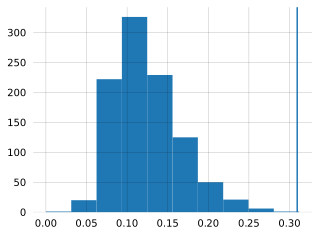

In [48]:
stat, p = der_dist_unif.test(x)
plt.hist(der_dist_unif.null_dists[x.size, x.sum(), :]) ;
plt.axvline(stat) ;
p

### General permutation null for any statistic

`NullDerDistUniform(stat=...)` generalises `DerDistUniform`: give it any statistic `stat(a)` of the 0/1 coalescence ordering (1 = derived) and it builds the Monte-Carlo permutation null and returns `test(x) -> (obs, p)`. `DerDistUniform()` is the special case `NullDerDistUniform(stat=derived_dist_uniform)`. `test()` uses a **mid-p** value by default so p-values stay uniform under H0 even for coarse/discrete statistics like the longest run (`stat=longest_derived_run`) — pass `mid=False` for the plain conservative value. For the longest run the exact `LongestDerRun` below is preferable; the Monte-Carlo version cross-checks it.

In [49]:
def derived_dist_uniform(a):
    """KS-type statistic: max deviation of the cumulative derived fraction from the diagonal."""
    n = np.asarray(a).cumsum()
    return abs(n / n[-1] - np.linspace(0, 1, n.size)).max()

def longest_derived_run(a):
    """Longest run of derived (1s) in the 0/1 array a."""
    return max((sum(g) for k, g in itertools.groupby(a) if k), default=0)


class NullDerDistUniform:
    """
    Monte-Carlo permutation null for an arbitrary statistic of the coalescence ordering.
    Generalises DerDistUniform: pass any `stat(a) -> float` mapping a 0/1 array
    (1 = derived) to a test statistic, e.g. NullDerDistUniform(stat=longest_derived_run).

    null_dists[size, ones, :] holds `rand_samples` values of stat() over random orderings
    of `ones` derived among `size` coalescences; cached to disk per
    (stat name, rand_samples, sample_size). test(x) -> (observed statistic, p-value).

    test() defaults to a mid-p value, which keeps the null distribution of the p-value
    ~uniform even for coarse/discrete statistics (e.g. the longest run); pass mid=False
    for the conservative (1 + #{null >= obs}) / (1 + B) value. (The original DerDistUniform
    used #{null >= obs} / B, which spikes at p=1 for discrete statistics, and left the
    last null sample uninitialised -- both fixed here.)
    """
    def __init__(self, stat, rand_samples=1000, sample_size=50):
        self.stat = stat
        cache_file_name = f'null_dists_{stat.__name__}_{rand_samples}_{sample_size}.npy'
        if os.path.exists(cache_file_name):
            self.null_dists = np.load(cache_file_name)
            return

        null_dists = np.full((sample_size+1, sample_size+1, rand_samples), np.nan)

        def null_dist(size, ones):
            x = np.array([1]*ones + [0]*(size-ones))
            return np.array([stat(np.random.choice(x, size=size, replace=False))
                             for _ in range(rand_samples)])

        args = [(size, ones) for size in range(1, sample_size+1) for ones in range(1, size)]
        with multiprocess.Pool(processes=cpus) as pool:
            for samples, (s, o) in zip(pool.starmap(null_dist, args), args):
                null_dists[s, o, :] = samples

        self.null_dists = null_dists
        np.save(cache_file_name, null_dists)

    def test(self, x, alternative='greater', mid=True):
        """Return (observed stat, p-value). alternative in {'greater','less','two-sided'};
        mid=True uses the mid-p value (keeps p uniform under H0 for discrete statistics)."""
        x = np.asarray(x)
        obs = self.stat(x)
        null = self.null_dists[x.size, x.sum(), :]
        B = null.size
        gt = (null > obs).sum(); lt = (null < obs).sum(); eq = (null == obs).sum()
        if mid:
            hi = (gt + 0.5 * (1 + eq)) / (B + 1)
            lo = (lt + 0.5 * (1 + eq)) / (B + 1)
        else:
            hi = (1 + gt + eq) / (1 + B)
            lo = (1 + lt + eq) / (1 + B)
        if alternative == 'greater':
            p = hi
        elif alternative == 'less':
            p = lo
        elif alternative == 'two-sided':
            p = min(1.0, 2 * min(hi, lo))
        else:
            raise ValueError(f"alternative must be 'greater', 'less', or 'two-sided', not {alternative!r}")
        return obs, p

`comb` callable with cache:

In [50]:
# from scipy.special import comb
import scipy

class Comb():

    cache = {}
    
    def __init__(self):
        pass

    def __call__(self, n, k, exact=True):
        if (n, k) not in self.cache:
            self.cache[(n, k)] = scipy.special.comb(n, k, exact=exact)
        return self.cache[(n, k)]

    @classmethod
    def clear(cls):
        cls.cache = {}

    def __enter__(self):

        def init_worker(data):
            # declare scope of a new global variable
            global comb
            # store argument in the global variable for this process
            comb = data
            
        self.pool = multiprocess.Pool(processes=cpus, initializer=init_worker, initargs=(self,))
        return self.pool

    def __exit__(self, type, value, tb):
        self.pool.close()

Comb().clear()
comb = Comb()

with Comb() as pool:
    pass
# pool = comb.multiprocess_pool()
# pool.close()

## Combinatorial results and functions for run probabilities

In [51]:
def get_coalescence_runs(all_times, clade_times):
    clade_times_set = set(clade_times)
    k, fn = 1, 1
    coalescence_runs = []
    first_derived_coal_found = False
    for t in all_times:
        is_derived = int( t in clade_times_set)
        if first_derived_coal_found:
            coalescence_runs.append(is_derived)
        if is_derived:
            # get all the coalescences *after* the first derived one. So that the first can be both 0 and 1
            first_derived_coal_found = True
    return np.array(coalescence_runs)

def get_runs_of_1s(bits):
    for bit, group in itertools.groupby(bits):
        if bit:
            yield sum(group)

def get_all_runs(bits):
    for bit, group in itertools.groupby(bits):
        if bit:
            yield sum(group)
    bits = np.absolute(bits - 1)
    for bit, group in itertools.groupby(bits):
        if bit:
            yield sum(group)

### PDF of the number of runs of zeros and ones

If r is odd:

$\displaystyle p(r) = \frac{\binom{n_1-1}{k} \binom{n_2-1}{k-1} + \binom{n_1-1}{k-1} \binom{n_2-1}{k} }{ \binom{n_1+n_2}{n_1}}$

where $\displaystyle k = \frac{r-1}{2}$

If r is even:

$\displaystyle p(r) = \frac{2 \binom{n_1-1}{k} \binom{n_2-1}{k-1} }{ \binom{n_1+n_2}{n_1}}$

where $\displaystyle k = \frac{r}{2}$


Got it [here](http://www.statistics4u.com/fundstat_eng/ee_runs_test.html)

In [52]:
def prob_nr_of_runs(n, n1, n2):
    """
    Probability of the number runs of either zeros or ones
    n: number of runs
    n0: nr zeros
    n1: nr ones
    """
    if n % 2:
        # uneven
        k = (n - 1) //  2
        return (comb(n1-1, k)*comb(n2-1, k-1) + comb(n1-1, k-1)*comb(n2-1, k)) / comb(n1+n2, n1)
    else:
        # even
        k = n // 2
        return 2*comb(n1-1, k-1)*comb(n2-1, k-1) / comb(n1+n2, n1)    

### The PDF over the number of occurences of runs with given length

Distribution of the random variable $E_{n,k}$ denoting the number of success runs of a fixed length $k$, $1 \le k \le n$:

$\displaystyle P(E_{n,k} = x) = \sum^{n-kx}_{y=0} p^{n-y} q^y \binom{y+1}{x} \sum^{\lfloor \frac{n-y-kx}{k} \rfloor}_{j=0} (-1)^j \binom{y+1-x}{j} \binom{n-(k+1)(x+j)}{n-y-k(x+j)} $

From ["On success runs of a fixed length in Bernoulli sequences: Exact and asymptotic results"](https://doi.org/10.1016/j.camwa.2010.12.023)

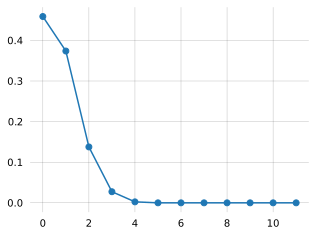

In [53]:
def pdf_number_of_1s_runs_with_len(n, k, p, x):
    q = 1-p
    prob = 0
    for y in range(0, (n-k*x)+1):
        prob += p**(n-y) * q**y * comb(y+1, x, exact=True) * sum(  (-1)**j * comb(y+1-x, j, exact=True) * comb(n-(k+1)*(x+j), n-y-k*(x+j), exact=True) for j in range(floor((n-y-k*x)/k)+1))
    return prob

n0, n1 = 4, 8
r = 2
x = list(range(n0+n1))
y = [pdf_number_of_1s_runs_with_len(n0+n1, r, n1/(n0+n1), n) for n in x]
plt.plot(x, y, 'o-');

### The the exact number and probability of a number of runs with a given length

The number of runs of a give length is:

$N^{i_k, k}_n = \displaystyle \sum^{n+1-(k+1)i_k}_{r=1} \binom{r+i_k}{i_k} \sum^{r}_{q=0} \sum^{q}_{j=0} (-1)^{q+j} \binom{r+m-1-kq-j}{m-kq-j} \binom{r}{q} \binom{q}{j} $

where $m = n+1-(k+1)i-r$.

The probability of occurrence of exactly $i_k$ runs of 1’s of length $k4$ in a given binary string of length $n$ is:

$ \displaystyle \frac{N^{i_k, k}_n}{2^n} $

From equation (3) in ["On the distribution of runs of ones in binary strings"](https://doi.org/10.1016/j.camwa.2009.07.057).

0.000244140625


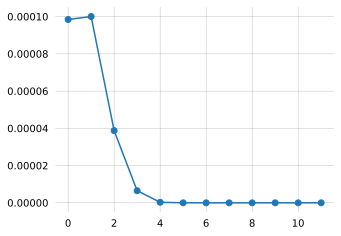

In [54]:
def nr_of_1s_runs_with_len(n, p, k, i):
    """
    The number of combinations with i runs of length k in a string of length n
    n: length
    p: probability of 1
    k: run length
    i: number of runs
    """    
    return sum( comb(r + i, i, exact=True) *
               sum(
                   sum( (-1)**(q + j) * comb(r + (n+1-(k+1)*i-r) - 1 - k*q - j, (n+1-(k+1)*i-r) - k*q - j, exact=True) * comb(r, q, exact=True) * comb(q, j, exact=True) \
                       for j in range(0, q+1))
                   for q in range(0, r+1))
               for r in range(1, (n+1-(k+1)*i)+1)) / 2**n

def prob_nr_of_1s_runs_with_len(n, p, k, i):
    """
    The probability of occurence of exactly i runs of 1's of length k in a string of length n
    n: length
    p: probability of 1
    k: run length
    i: number of runs
    """    
    return nr_of_1s_runs_with_len(n, p, k, i) / 2**n

#prob_nr_of_1s_runs_with_len(n=8, p=0.5, k=2, i=2)

n0, n1 = 4, 8
r = 2
x = list(range(n0+n1))
y = [prob_nr_of_1s_runs_with_len(n0+n1, n1/(n0+n1), r, n) for n in x]
print(sum(y))
plt.plot(x, y, 'o-');


### Probability of the longest run of ones

$P(L_n = k) = p^n \displaystyle \sum^{n-k}_{y=\lfloor n/k+1 \rfloor} (q/p)^y \sum^{y+1}_{i=1} \binom{y+1}{i}  C(n-y-ik, y+1-i, k-1)$

where

$\displaystyle C(\alpha, r, k) = \sum^r_{j=0} (-1)^j \binom{r}{j} \binom{a-(k+1)j + r - 1}{r-1} $

From equations (2) and (7) in ["Shortest and longest length of success runs in binary sequences"](https://doi:10.1016/j.jspi.2006.07.007).

0.9999799728916514


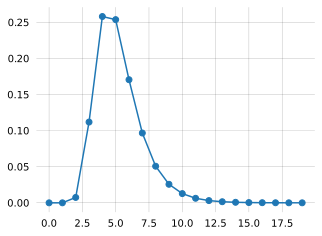

In [55]:
def prob_longest_1s_run(n, k, p):
    q = 1-p
    def C(a, r, k):
        return sum( (-1)**j * comb(r, j, exact=True) * comb(a - (k+1)*j + r - 1, r-1, exact=True) for j in range(0, r+1))
    return p**n * sum( (q/p)**y * sum( comb(y+1, i, exact=True) * C(n-y-i*k, y+1-i, k-1) for i in range(1, ((y+1)+1))) for y in range(floor(n/(k+1)), (n-k)+1) )


prob_longest_1s_run(10, 6, 0.5)

n0, n1 = 30, 30
r = 15
x = list(range(20))
y = [prob_longest_1s_run(n0+n1, r, n1/(n0+n1)) for r in x]
print(sum(y))
plt.plot(x, y, 'o-');

### Compute cached probabilities

### Probability of the longest run of derived (exact permutation null)

Test the longest derived run against the **permutation null**: condition on exactly $n_1$ derived among $n=n_0+n_1$ coalescences, with every ordering equally likely. (The i.i.d. Bernoulli($p$) formula `prob_longest_1s_run` mis-states the tails at fixed sample size.) The longest derived run $L$ then has the exact distribution

$$P(L \le m) = \frac{\sum_{j} (-1)^j \binom{n_0+1}{j}\binom{n_1 - j(m+1) + n_0}{n_0}}{\binom{n_0+n_1}{n_1}}$$

— distribute the $n_1$ derived into the $n_0+1$ gaps around the ancestral coalescences, at most $m$ per gap. The next cell builds `prob_longest_der_run_cache[n0, n1, k] = P(L = k)` from this with exact-integer binomials (float64 vectorization is numerically unsafe here — see the comment). Verified exact against full enumeration and Monte-Carlo, and wrapped in the `LongestDerRun` test class below.

In [56]:
recompute = False

In [57]:
%%time
def longest_der_run_pmf(n0, n1):
    """
    Exact distribution of the longest run of derived (1s) given n1 derived and n0
    ancestral coalescences under the permutation null (all C(n0+n1, n1) orderings
    equally likely).  Returns pmf with pmf[k] = P(longest derived run == k), k = 0..n1.

        P(L <= m) = sum_j (-1)^j C(n0+1, j) C(n1 - j(m+1) + n0, n0) / C(n0+n1, n1)
    """
    total = comb(n0 + n1, n1)
    cdf = np.empty(n1 + 1)
    for m in range(n1 + 1):
        cap = m + 1
        cdf[m] = sum((-1)**j * comb(n0 + 1, j) * comb(n1 - j*cap + n0, n0)
                     for j in range(n1 // cap + 1)) / total
    pmf = np.empty(n1 + 1); pmf[0] = cdf[0]; pmf[1:] = np.diff(cdf)
    return np.clip(pmf, 0, None)

# prob_longest_der_run_cache[n0, n1, k] = P(longest derived run == k), exact permutation null.
# Built with exact-integer binomials (the cached `comb`): float64 vectorization is unsafe
# here -- the inclusion-exclusion catastrophically cancels huge binomials for large n0+n1
# (error ~1e2 for total > 100), and exact ints are already fast (~1 s for N=100).
N = 100
prob_longest_der_run_cache = np.full((N+1, N+1, 2*N+1), np.nan)
for n0 in range(N+1):
    for n1 in range(1, N+1):
        pmf = longest_der_run_pmf(n0, n1)
        prob_longest_der_run_cache[n0, n1, :pmf.size] = pmf

np.save('prob_longest_der_run_cache.npy', prob_longest_der_run_cache)

CPU times: user 1.76 s, sys: 23 ms, total: 1.78 s
Wall time: 1.79 s


Proability of the number of ancestral and derived runs:

In [58]:
if recompute:
    with multiprocess.Pool(processes=cpus) as pool:
        n = 100
        dim = 2*n+1
        cache = np.ndarray(shape=(n+1, n+1, 2*n+1), dtype=float)
        cache[:, :, :] = np.nan
        for n0 in tqdm(range(1, n+1)):
            for n1 in range(1, n+1):
                for r in range(1, n0+n1):
                    cache[n0, n1, r] = prob_nr_of_runs(r, n0, n1)

    np.save('prob_nr_of_runs_cache.npy', cache)
    
prob_nr_of_runs_cache = np.load('prob_nr_of_runs_cache.npy')

### Analyze pvalues

#### The mid-p value

The statistics here (number of runs, longest run) are **discrete**, so the ordinary one-sided p-value $P(T \ge t_\text{obs})$ is *not* Uniform(0,1) under H₀: it can only take the finitely many values of the survival function, it is conservative ($E[p] > \tfrac12$), and it carries a probability atom of size $P(T=t_\text{max})$ sitting exactly at **p = 1** (the lower-tail version, an atom at 0). Those atoms are what produced the earlier spikes at 0 and 1.

The **mid-p value** puts only *half* of the observed outcome's probability into the tail:

$$p_\text{mid} \;=\; P(T > t_\text{obs}) + \tfrac12\,P(T = t_\text{obs}) \;=\; \tfrac12\big[\,P(T > t_\text{obs}) + P(T \ge t_\text{obs})\,\big],$$

i.e. the average of the "$>$" and "$\ge$" p-values. Under H₀ it has mean exactly $\tfrac12$ and no edge atoms, so the null histogram is ~flat; the price is that it is no longer strictly conservative (it can slightly exceed the nominal level in tiny samples). See [(Lancaster, 1961)](https://doi.org/10.1080/01621459.1961.10482117).

One residue is unavoidable: for a **near-deterministic** statistic (lopsided splits, $\min(n_0,n_1)\lesssim\sqrt{n}$) almost all mass sits on a single value $v$, so $p_\text{mid}\approx 0+\tfrac12\cdot 1=\tfrac12$ — the atom that used to sit at 1 is now parked at **0.5**. The analysis cells below skip those splits ($\min(n_0,n_1)\ge\sqrt{n}$).

#### longest_1s_run

In [59]:
class LongestDerRun:
    """
    Exact permutation null for the longest run of derived coalescences.

    Conditions on the number of derived (n1) among n = n0 + n1 coalescences, with every
    ordering equally likely -- the proper null (not the i.i.d. Bernoulli(p) approximation
    of prob_longest_1s_run). Mirrors DerDistUniform.test(): returns (observed statistic,
    p-value), with a mid-p correction for the discreteness of the statistic.
    """
    def __init__(self):
        self._pmf = {}                       # (n0, n1) -> exact pmf, memoised

    @staticmethod
    def stat(x):
        """Longest run of derived (1s) in the 0/1 array x."""
        return max(get_runs_of_1s(np.asarray(x)), default=0)

    def pmf(self, n0, n1):
        """Exact pmf[k] = P(longest derived run == k), k = 0..n1."""
        if (n0, n1) not in self._pmf:
            self._pmf[(n0, n1)] = longest_der_run_pmf(n0, n1)
        return self._pmf[(n0, n1)]

    def test(self, x, alternative='greater'):
        """
        Return (L_obs, p). alternative='greater' gives the upper-tail mid-p value
        P(L > L_obs) + 0.5 P(L = L_obs) -- selection clusters derived coalescences into
        longer runs; use 'less' for the lower tail.
        """
        x = np.asarray(x)
        n1 = int(x.sum()); n0 = int(x.size) - n1
        obs = self.stat(x)
        pmf = self.pmf(n0, n1)
        if alternative == 'greater':
            surv = np.concatenate([np.cumsum(pmf[::-1])[::-1], [0.0]])  # surv[k] = P(L >= k)
            return obs, surv[obs + 1] + 0.5 * pmf[obs]
        if alternative == 'less':
            cdf = np.cumsum(pmf)
            return obs, cdf[obs] - 0.5 * pmf[obs]
        raise ValueError(f"alternative must be 'greater' or 'less', not {alternative!r}")


longest_der_run = LongestDerRun()
x = np.array([1,1,1,1,0,1,1,0,1,1,1,1,0,1,1,1,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1])
longest_der_run.test(x)

(np.int64(5), np.float64(0.3754635625633152))

In [60]:
def prob_longest_1s_run(n, k, p):
    q = 1-p
    def C(a, r, k):
        return sum( (-1)**j * comb(r, j, exact=True) * comb(a - (k+1)*j + r - 1, r-1, exact=True) for j in range(0, r+1))
    return p**n * sum( (q/p)**y * sum( comb(y+1, i, exact=True) * C(n-y-i*k, y+1-i, k-1) for i in range(1, ((y+1)+1))) for y in range(floor(n/(k+1)), (n-k)+1) )


In [61]:


der_dist_unif = NullDerDistUniform(stat=derived_dist_uniform)
x = np.array([1,1,1,1,0,1,1,0,1,1,1,1,0,1,1,1,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,1])
der_dist_unif.test(x)

(np.float64(0.30952380952380953), np.float64(0.0004995004995004995))

np.float64(0.0004995004995004995)

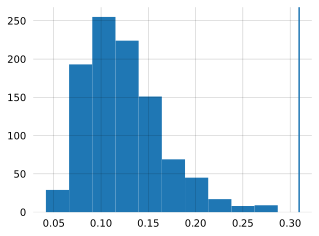

In [62]:
stat, p = der_dist_unif.test(x)
plt.hist(der_dist_unif.null_dists[x.size, x.sum(), :]) ;
plt.axvline(stat) ;
p

In [ ]:
pvalues = []
n = 100
lo = round(n**0.5)   # skip lopsided splits: where min(n0,n1) < ~sqrt(n) the longest run is
                     # near-deterministic, so its mid-p collapses onto ~0.5 (the peak we saw)
for n1 in range(lo, n - lo + 1):
    n0 = n - n1
    for _ in range(1000):
        runs = np.array(([1] * n1) + ([0]*n0))
        np.random.shuffle(runs)
        _, p = longest_der_run.test(runs)   # exact permutation null, upper-tail mid-p
        pvalues.append(p)

KeyboardInterrupt: 

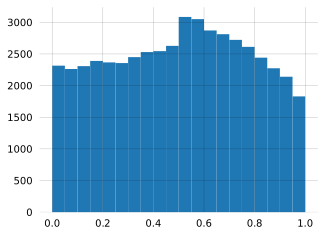

In [ ]:
plt.hist(pvalues, bins=20) ;

#### nr_runs

In [ ]:
pvalues = []
n = 100
# lo = round(n**0.5)   # skip lopsided splits: where min(n0,n1) < ~sqrt(n) the run count is
#                      # near-deterministic, so its mid-p collapses onto ~0.5 (the peak we saw)
#for n1 in range(lo, n - lo + 1):
# for n1 in range(1, n):
for n1 in [20]:
    n0 = n - n1
    for _ in range(10000):
        runs = np.array(([1] * n1) + ([0]*n0))
        np.random.shuffle(runs)
        nr_runs = np.fromiter(get_all_runs(runs), int).size
        # mid-p value: removes the discreteness atom that otherwise piles up at p=1
        cum = sum(prob_nr_of_runs(x, n0, n1) for x in range(1, nr_runs+1))
        pvalue = cum #- 0.5 * prob_nr_of_runs(nr_runs, n0, n1)
        pvalues.append(pvalue)




print(pvalues.count(1))
pvalues = [p for p in pvalues if p < 1]
pvalues.append(pvalue)        

48


P-values are uniform (except the atom at 1) only if all n1 are equally likely and we do not assume an n1 - which we would in an observation.

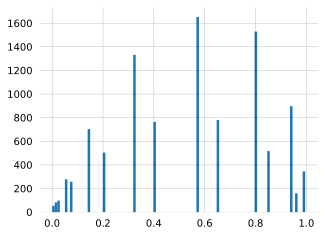

In [156]:
plt.hist(pvalues, bins=100) ;